In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/menegidio/iris-species/Iris.csv
/kaggle/input/datasets/menegidio/iris-species/database.sqlite


## 1. Importação das bibliotecas e carregamento dos dados
Nesta etapa importamos as bibliotecas necessárias: pandas para manipular a tabela, matplotlib para os gráficos e o scikit-learn para os modelos, a divisão treino/teste, o GridSearchCV e as métricas. Em seguida lemos o arquivo Iris.csv, que já está anexado ao notebook, e mostramos as primeiras linhas para conferir se os dados foram carregados corretamente.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, recall_score, classification_report, confusion_matrix

df = pd.read_csv('/kaggle/input/datasets/menegidio/iris-species/Iris.csv')
print('Formato do dataset:', df.shape)
df.head()

Formato do dataset: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## 2. Exploração inicial
Antes de treinar, verificamos três coisas: quantas amostras existem de cada espécie (para saber se as classes são balanceadas), se há valores nulos e o resumo estatístico das medidas das flores. O Iris tem 150 amostras, 50 de cada espécie, então não precisamos tratar desbalanceamento.

In [3]:
print('Amostras por espécie:')
print(df['Species'].value_counts())
print('\nValores nulos por coluna:')
print(df.isnull().sum())
df.describe()

Amostras por espécie:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Valores nulos por coluna:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


## 3. Preparação dos dados
Separamos as variáveis de entrada (as quatro medidas das flores) do alvo (a espécie), removendo a coluna Id, que é só um identificador. Dividimos os dados em 70% para treino e 30% para teste, usando `stratify` para manter a proporção das espécies nos dois conjuntos e `random_state=42` para que o resultado seja reproduzível.

Também padronizamos os dados com o StandardScaler. Isso é necessário para o SVM, que é sensível à escala das variáveis. O scaler aprende apenas com o treino e depois é aplicado ao teste, evitando vazamento de informação. Árvore, Floresta e Boosting não dependem da escala e usarão os dados originais.

In [4]:
X = df.drop(columns=['Id', 'Species'])
y = df['Species']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Treino:', X_train.shape, '| Teste:', X_test.shape)

Treino: (105, 4) | Teste: (45, 4)


## 4. Métricas de avaliação
Vamos comparar os modelos por duas métricas:

1. **Acurácia:** proporção de previsões corretas sobre o total.
2. **Sensibilidade (recall):** entre as flores que realmente pertencem a uma espécie, quanto o modelo conseguiu identificar. Como temos três classes, usamos a média das sensibilidades das três espécies (`average='macro'`), dando o mesmo peso a cada uma.

A função abaixo recebe um modelo já treinado e devolve as duas métricas calculadas no conjunto de teste.

In [5]:
def avaliar(nome, modelo, X_teste):
    pred = modelo.predict(X_teste)
    return {
        'Modelo': nome,
        'Acurácia': accuracy_score(y_test, pred),
        'Sensibilidade': recall_score(y_test, pred, average='macro')
    }

svm_teste = SVC(random_state=42).fit(X_train_s, y_train)
pd.DataFrame([avaliar('SVM (teste da função)', svm_teste, X_test_s)]).set_index('Modelo').round(4)

,Acurácia,Sensibilidade
Modelo,,
SVM (teste da função),0.9333,0.9333


## 5. Modelos sem GridSearchCV
Aqui treinamos os quatro modelos com os hiperparâmetros padrão do scikit-learn: SVM, Árvore de Decisão, Floresta Aleatória e Boosting (Gradient Boosting). O SVM usa os dados padronizados e os demais usam os dados originais. No final, montamos uma tabela com acurácia e sensibilidade de cada um, que será nossa linha de base para comparar com a versão otimizada.

In [6]:
modelos_sem = {
    'SVM': (SVC(random_state=42), X_train_s, X_test_s),
    'Árvore de Decisão': (DecisionTreeClassifier(random_state=42), X_train, X_test),
    'Floresta Aleatória': (RandomForestClassifier(random_state=42), X_train, X_test),
    'Boosting': (GradientBoostingClassifier(random_state=42), X_train, X_test),
}

resultados = []
for nome, (modelo, Xtr, Xte) in modelos_sem.items():
    modelo.fit(Xtr, y_train)
    resultados.append(avaliar(nome, modelo, Xte))

res_sem = pd.DataFrame(resultados).set_index('Modelo').round(4)
res_sem

,Acurácia,Sensibilidade
Modelo,,
SVM,0.9333,0.9333
Árvore de Decisão,0.9333,0.9333
Floresta Aleatória,0.8889,0.8889
Boosting,0.9333,0.9333


## 6. Modelos com GridSearchCV
O GridSearchCV testa várias combinações de hiperparâmetros para cada modelo, avaliando cada combinação com validação cruzada de 5 partes (`cv=5`) apenas nos dados de treino. A melhor combinação, escolhida pela acurácia, é usada para refazer o treino e só então o modelo é avaliado no conjunto de teste.

Grades testadas:
1. **SVM:** `C`, `kernel` e `gamma`.
2. **Árvore de Decisão:** `criterion`, `max_depth` e `min_samples_split`.
3. **Floresta Aleatória:** `n_estimators`, `max_depth` e `min_samples_split`.
4. **Boosting:** `n_estimators`, `learning_rate` e `max_depth`.

A tabela final mostra as métricas e os melhores parâmetros encontrados para cada modelo.

In [7]:
grades = {
    'SVM': (
        SVC(random_state=42),
        {'C': [0.1, 1, 10, 100], 'kernel': ['linear', 'rbf'], 'gamma': ['scale', 0.1, 0.01]},
        X_train_s, X_test_s),
    'Árvore de Decisão': (
        DecisionTreeClassifier(random_state=42),
        {'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, 4, 5, None], 'min_samples_split': [2, 5, 10]},
        X_train, X_test),
    'Floresta Aleatória': (
        RandomForestClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'max_depth': [None, 3, 5], 'min_samples_split': [2, 5]},
        X_train, X_test),
    'Boosting': (
        GradientBoostingClassifier(random_state=42),
        {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.1, 0.2], 'max_depth': [2, 3]},
        X_train, X_test),
}

melhores = {}
resultados = []
for nome, (modelo, grade, Xtr, Xte) in grades.items():
    gs = GridSearchCV(modelo, grade, cv=5, scoring='accuracy', n_jobs=-1)
    gs.fit(Xtr, y_train)
    melhores[nome] = (gs.best_estimator_, Xte)
    linha = avaliar(nome, gs.best_estimator_, Xte)
    linha['Melhores parâmetros'] = gs.best_params_
    resultados.append(linha)

res_com = pd.DataFrame(resultados).set_index('Modelo')
res_com[['Acurácia', 'Sensibilidade']] = res_com[['Acurácia', 'Sensibilidade']].round(4)
res_com

,Acurácia,Sensibilidade,Melhores parâmetros
Modelo,,,
SVM,0.9111,0.9111,"{'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}"
Árvore de Decisão,0.9778,0.9778,"{'criterion': 'gini', 'max_depth': 3, 'min_sam..."
Floresta Aleatória,0.9111,0.9111,"{'max_depth': 3, 'min_samples_split': 5, 'n_es..."
Boosting,0.9333,0.9333,"{'learning_rate': 0.01, 'max_depth': 2, 'n_est..."


## 7. Comparação entre os modelos
Juntamos os resultados sem e com GridSearchCV em uma única tabela e em um gráfico de barras, para ver lado a lado qual modelo tem maior acurácia e maior sensibilidade e se a busca de hiperparâmetros trouxe ganho.

,Acurácia (sem Grid),Sensibilidade (sem Grid),Acurácia (com Grid),Sensibilidade (com Grid)
Modelo,,,,
SVM,0.9333,0.9333,0.9111,0.9111
Árvore de Decisão,0.9333,0.9333,0.9778,0.9778
Floresta Aleatória,0.8889,0.8889,0.9111,0.9111
Boosting,0.9333,0.9333,0.9333,0.9333


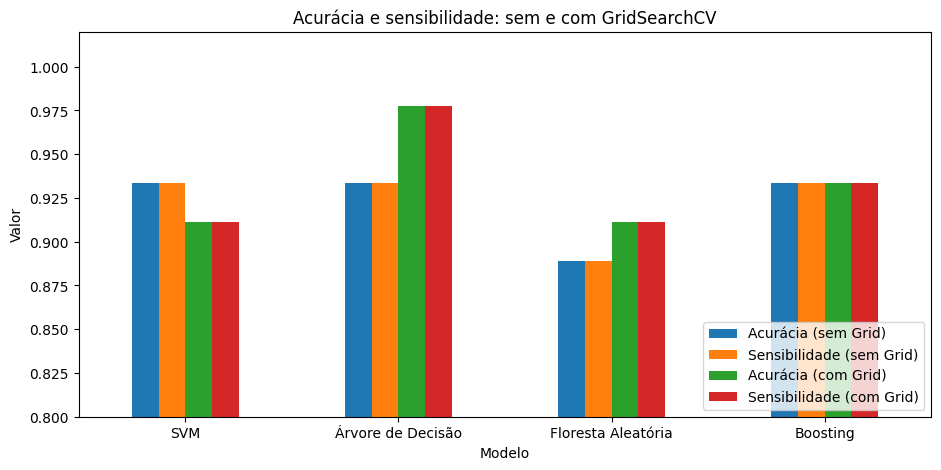

In [8]:
comp = pd.concat([
    res_sem.add_suffix(' (sem Grid)'),
    res_com[['Acurácia', 'Sensibilidade']].add_suffix(' (com Grid)')
], axis=1)
display(comp)

comp.plot(kind='bar', figsize=(11, 5))
plt.title('Acurácia e sensibilidade: sem e com GridSearchCV')
plt.ylabel('Valor')
plt.ylim(0.8, 1.02)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()

## 8. Desempenho por espécie (modelos com GridSearchCV)
A média esconde em qual espécie cada modelo erra. Para os modelos otimizados, mostramos o relatório de classificação (a coluna recall é a sensibilidade de cada espécie) e a matriz de confusão, em que as linhas são as espécies reais e as colunas são as previstas. Valores fora da diagonal são erros.

In [9]:
for nome, (modelo, Xte) in melhores.items():
    pred = modelo.predict(Xte)
    print('=' * 50)
    print(nome)
    print(classification_report(y_test, pred))
    print('Matriz de confusão:')
    print(confusion_matrix(y_test, pred))
    print()

SVM
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45

Matriz de confusão:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Árvore de Decisão
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      0.93      0.97        15
 Iris-virginica       0.94      1.00      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45

Matriz de confusão:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

Floresta Aleatória
                 precision    recall  f

## 9. Qual modelo é o melhor?
O código abaixo indica, dentre todas as versões (sem e com GridSearchCV), a que obteve maior acurácia e a que obteve maior sensibilidade. Ele só aponta o primeiro colocado em caso de empate, então confira a tabela do passo 7.

In [10]:
todos = pd.concat([
    res_sem.assign(Versão='Sem Grid'),
    res_com[['Acurácia', 'Sensibilidade']].assign(Versão='Com Grid')
]).reset_index()

print('Maior acurácia:')
print(todos.loc[todos['Acurácia'].idxmax(), ['Modelo', 'Versão', 'Acurácia']].to_string())
print('\nMaior sensibilidade:')
print(todos.loc[todos['Sensibilidade'].idxmax(), ['Modelo', 'Versão', 'Sensibilidade']].to_string())

Maior acurácia:
Modelo      Árvore de Decisão
Versão               Com Grid
Acurácia               0.9778

Maior sensibilidade:
Modelo           Árvore de Decisão
Versão                    Com Grid
Sensibilidade               0.9778


## 9.1 Verificação com várias divisões treino/teste
O passo 9 aponta a Árvore de Decisão, mas esse resultado vale só para uma divisão, com apenas 45 amostras de teste. Para saber se ele se sustenta, repetimos o experimento com várias divisões diferentes e calculamos a média e o desvio padrão da acurácia. Como o teste é sempre balanceado (15 amostras por espécie), a sensibilidade média é igual à acurácia, então mostramos só a acurácia. O primeiro resultado é sem GridSearchCV, com 30 divisões. O segundo é com GridSearchCV, com 10 divisões, porque cada uma leva mais tempo.

In [11]:
bases = {
    'SVM': (SVC(random_state=42), grades['SVM'][1], True),
    'Árvore de Decisão': (DecisionTreeClassifier(random_state=42), grades['Árvore de Decisão'][1], False),
    'Floresta Aleatória': (RandomForestClassifier(random_state=42), grades['Floresta Aleatória'][1], False),
    'Boosting': (GradientBoostingClassifier(random_state=42), grades['Boosting'][1], False),
}

def repetir(n_divisoes, com_grid):
    acc = {nome: [] for nome in bases}
    for seed in range(100, 100 + n_divisoes):
        Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=seed, stratify=y)
        sc = StandardScaler().fit(Xtr)
        for nome, (modelo, grade, escala) in bases.items():
            a, b = (sc.transform(Xtr), sc.transform(Xte)) if escala else (Xtr, Xte)
            if com_grid:
                modelo = GridSearchCV(modelo, grade, cv=5, scoring='accuracy', n_jobs=-1)
            acc[nome].append(accuracy_score(yte, modelo.fit(a, ytr).predict(b)))
    return pd.DataFrame({
        'Acurácia média': {n: np.mean(v) for n, v in acc.items()},
        'Desvio padrão': {n: np.std(v) for n, v in acc.items()}
    }).round(4)

print('Sem GridSearchCV (30 divisões):')
display(repetir(30, False))
print('Com GridSearchCV (10 divisões):')
display(repetir(10, True))

Sem GridSearchCV (30 divisões):


,Acurácia média,Desvio padrão
SVM,0.9578,0.0265
Árvore de Decisão,0.9378,0.0311
Floresta Aleatória,0.9511,0.0311
Boosting,0.9511,0.0289


Com GridSearchCV (10 divisões):


,Acurácia média,Desvio padrão
SVM,0.9489,0.0264
Árvore de Decisão,0.9267,0.0264
Floresta Aleatória,0.9378,0.0356
Boosting,0.9356,0.0321


## 10. Conclusão
**Resultado na divisão do notebook (random_state=42):** a Árvore de Decisão com GridSearchCV teve a maior acurácia e sensibilidade (97,78%), seguida pelo Boosting (93,33%). SVM e Floresta Aleatória ficaram em 91,11% com GridSearchCV. Sem GridSearchCV, SVM, Árvore e Boosting empataram em 93,33% e a Floresta teve 88,89%.

O conjunto de teste tem só 45 amostras, e cada erro vale cerca de 2,2 pontos percentuais. Repetindo o experimento com 30 divisões treino/teste diferentes, sem GridSearchCV, o SVM teve a maior média (95,78%), seguido por Floresta Aleatória e Boosting (95,11%) e pela Árvore de Decisão (93,78%). Com GridSearchCV (10 divisões), a ordem se manteve: SVM 94,89%, Floresta 93,78%, Boosting 93,56% e Árvore 92,67%. O desvio padrão de cerca de 3 pontos é maior que a distância entre os modelos, então os quatro são estatisticamente equivalentes neste dataset.

**Sensibilidade:** como as três espécies têm o mesmo número de amostras no teste, a sensibilidade média (recall macro) é idêntica à acurácia, e o ranking dos modelos é o mesmo nas duas métricas. Todos os erros ocorrem entre *Iris-versicolor* e *Iris-virginica*, enquanto a *Iris-setosa* é sempre classificada corretamente.

**Efeito do GridSearchCV:** não houve ganho consistente. Em uma divisão ele melhorou alguns modelos e piorou outros, e na média não superou os modelos com parâmetros padrão.

**Conclusão:** o SVM é a melhor escolha, por ter a maior média de acurácia e sensibilidade nos dois cenários, sendo ainda simples e dispensando ajuste de hiperparâmetros. A Árvore de Decisão otimizada, que ganhou na divisão 42, deve esse resultado à sorte da divisão e não a uma superioridade real. Os modelos têm desempenho muito próximo no Iris.